In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np

from tqdm import tqdm
sys.path.insert(0, "./")

%load_ext autoreload
%autoreload 2

%matplotlib inline

In [2]:
import src

# algorithm

In [4]:
# # ### cut the problem for simplicity
# import src.preproc_utils as prep
# diff_path = "./data/diffs/"
# # mask = np.load("./data/processed/mask.npy")
# state = np.load(os.path.join(diff_path, "state0.npy"))
# diffs = np.load(os.path.join(diff_path, "diffs.npy"))
# video = prep.rgb2gray(src.video_utils.get_frames(os.path.join(src.DATAPATH, "processed/cut_aligned_gray.MP4")))
# # ### slice by [:, 20:160, 500:1500]
# np.save(os.path.join("./data/_ex_small/diffs.npy"), diffs[:, 20:160, 500:1500])
# np.save(os.path.join("./data/_ex_small/video.npy"), video[:, 20:160, 500:1500])
# np.save(os.path.join("./data/_ex_small/state0.npy"), state0[20:160, 500:1500])
# np.save(os.path.join("./data/_ex_small/tube_mask.npy"), mask[20:160, 500:1500])

diffs = np.load(os.path.join("./data/_ex_small/diffs.npy"))
diffs = (diffs > 0).astype(np.uint8)

video = np.load(os.path.join("./data/_ex_small/video.npy"))
vid = np.concatenate([video[...,None]] * 3, axis=-1)

state0 = np.load(os.path.join("./data/_ex_small/state0.npy"))
tube_mask = np.load(os.path.join("./data/_ex_small/tube_mask.npy"))
print(diffs.shape, video.shape, state0.shape, tube_mask.shape)


(117, 140, 1000) (118, 140, 1000) (140, 1000) (140, 1000)


In [5]:
from src.vis_utils import blend_w_masks

from src.alg import denoise_and_fill

num_future = 10

blend_vid = blend_w_masks(vid, diffs, num_future=num_future, alpha=0.4)
src.utils.write_frames(blend_vid, os.path.join(src.DATAPATH, f"_ex_small/blend_w_future_masks_{num_future}_raw.mp4"), fps=20)

blend_vid = blend_w_masks(vid, np.stack([denoise_and_fill(d) for d in tqdm(diffs)]), num_future=num_future, alpha=0.4)
src.utils.write_frames(blend_vid, os.path.join(src.DATAPATH, f"_ex_small/blend_w_future_masks_{num_future}.mp4"), fps=20)



100%|██████████| 117/117 [00:00<00:00, 3718.64it/s]


In [6]:
from src.alg import State

state = State(tube_mask=tube_mask, output_kernel_size=(9,9))

diffs = np.load(os.path.join("./data/_ex_small/diffs.npy"))
diffs = (diffs > 0).astype(np.uint8)
for y in tqdm(diffs):
    state.update(y)

states = state.get_states()
diffs = state.get_diffs()

src.utils.write_frames(
    blend_w_masks(vid, diffs, num_future=1, alpha=0.3, num_colors_total=1), 
    os.path.join(src.DATAPATH, f"_ex_small/blend_w_masks1.mp4"), fps=20)

src.utils.write_frames(
    blend_w_masks(vid, states, num_future=1, alpha=0.3, num_colors_total=1), 
    os.path.join(src.DATAPATH, f"_ex_small/blend_w_states0.mp4"), fps=20)


src.video_utils.stack_videos(
    [   
        os.path.join(src.DATAPATH, f"_ex_small/blend_w_masks1.mp4"),
        os.path.join(src.DATAPATH, f"_ex_small/orig.mp4"),
        os.path.join(src.DATAPATH, f"_ex_small/blend_w_states0.mp4"),
    ],
    os.path.join(src.DATAPATH, f"_ex_small/masks_orig_states__kernel_99.mp4"), axis=0
)



100%|██████████| 117/117 [00:00<00:00, 267.81it/s]


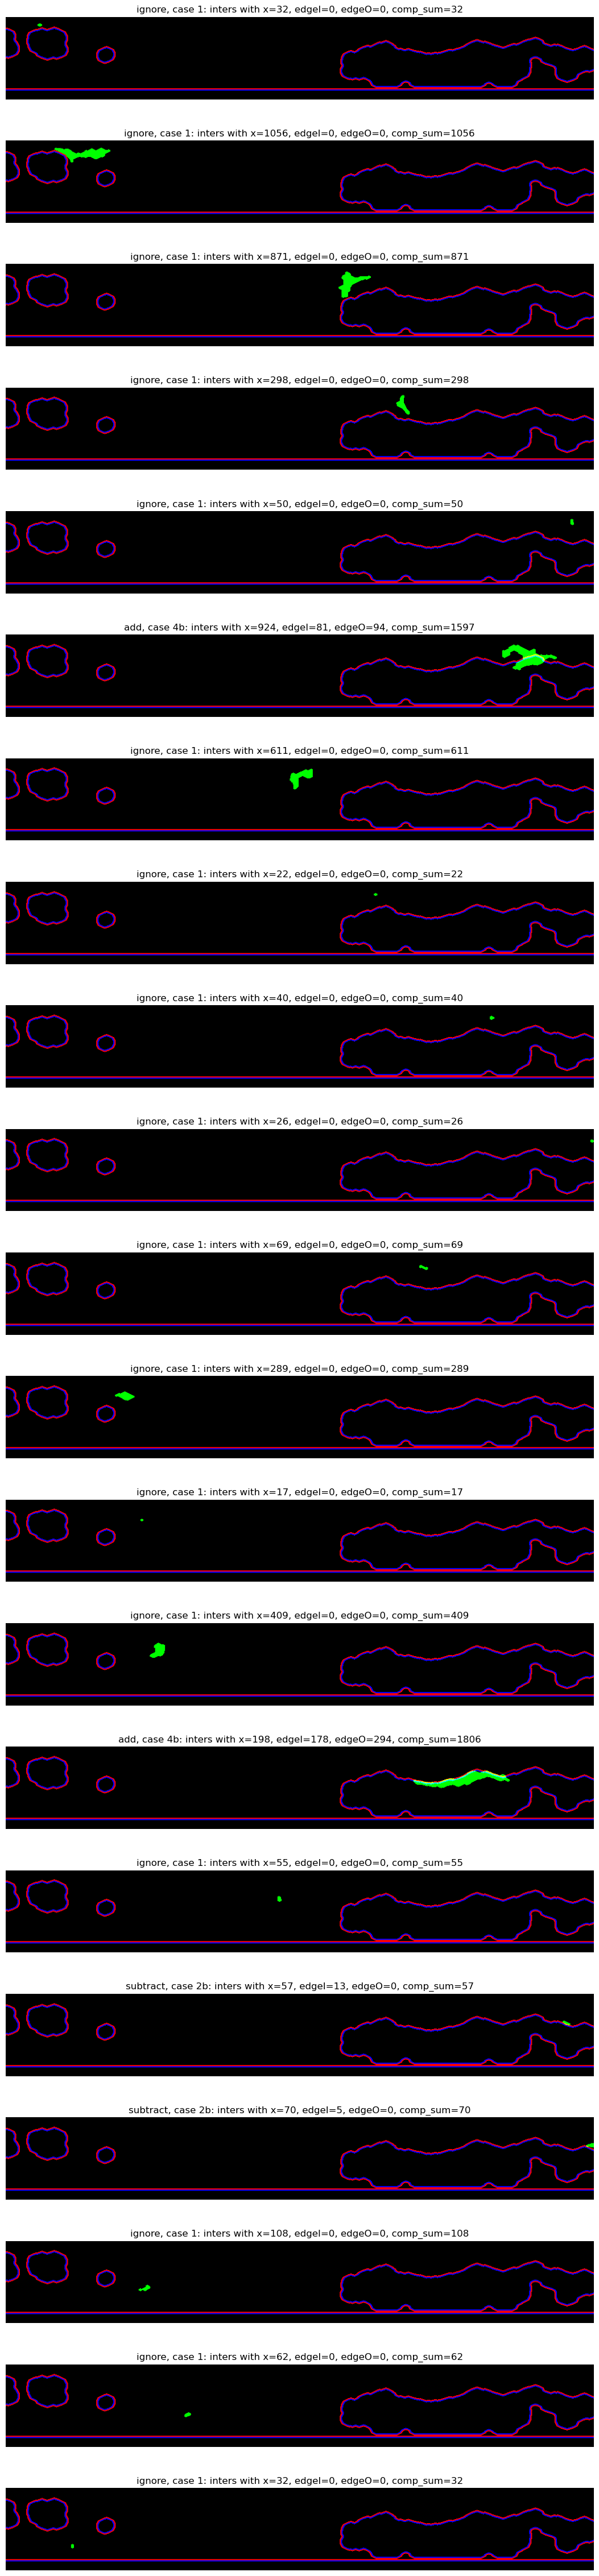

In [7]:
from src.test_alg import _test_comp_update

idx = 97
_ = _test_comp_update(idx, state)